In [4]:
!pip install catboost -q

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, classification_report,
    precision_recall_curve, roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

HAS_XGB = False
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    pass

HAS_LGBM = False
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    pass

HAS_CATBOOST = False
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    pass

RANDOM_STATE = 42
N_ITER = 20
CV_FOLDS = 3

import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
train_raw = pd.read_csv("/content/sample_data/aug_train.csv")
test_raw = pd.read_csv("/content/sample_data/aug_test.csv")

df = train_raw.copy()
test_df = test_raw.copy()

In [7]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [9]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [10]:
df.duplicated().sum()


np.int64(0)

## Exploratory Data Analysis (EDA)

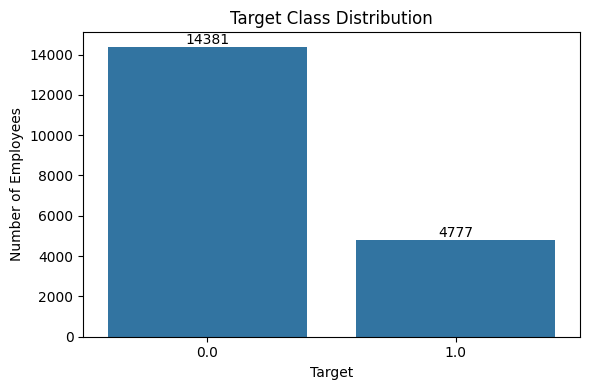

Target proportions:
target
0.0    0.750652
1.0    0.249348
Name: proportion, dtype: float64


In [11]:
# Target distribution
target_counts = train_raw["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=target_counts.index.astype(str), y=target_counts.values)
plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

print("Target proportions:")
print(train_raw["target"].value_counts(normalize=True).sort_index())


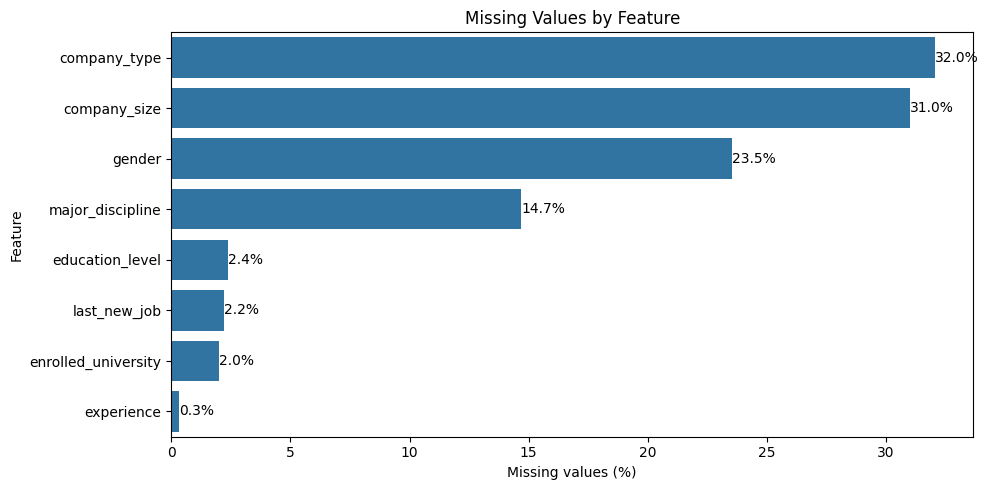

In [12]:
# Missing-value overview
missing_pct = (
    train_raw.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.title("Missing Values by Feature")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()


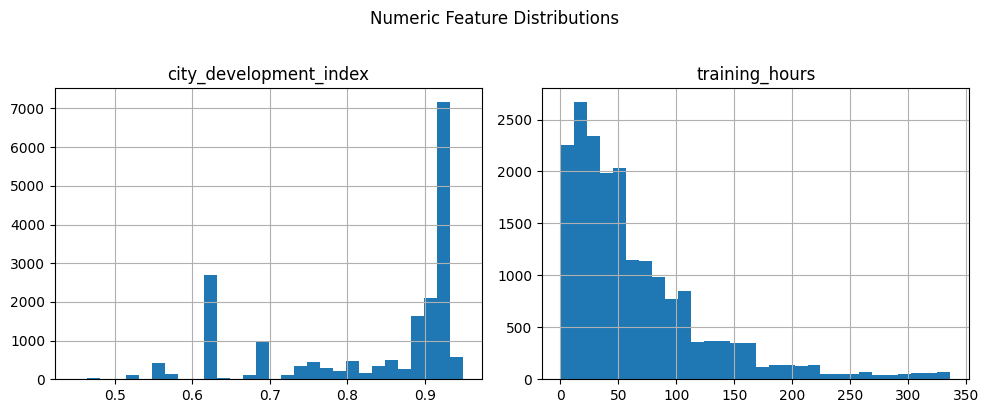

In [13]:
# Numeric feature distributions
eda_numeric = [
    "city_development_index",
    "training_hours",
]

train_raw[eda_numeric].hist(
    bins=30,
    figsize=(10, 4)
)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


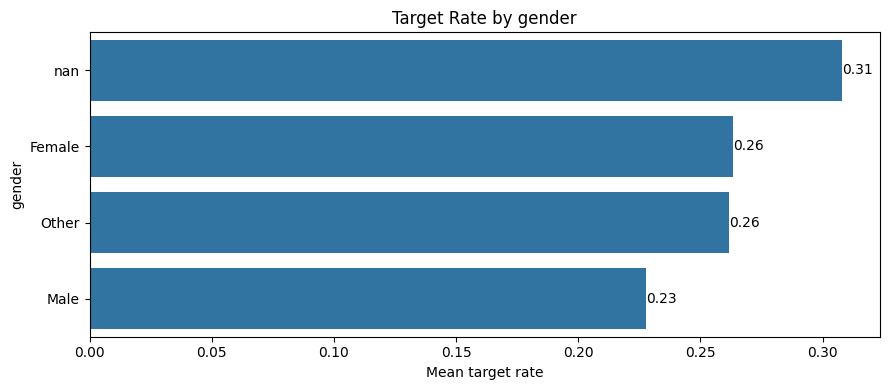

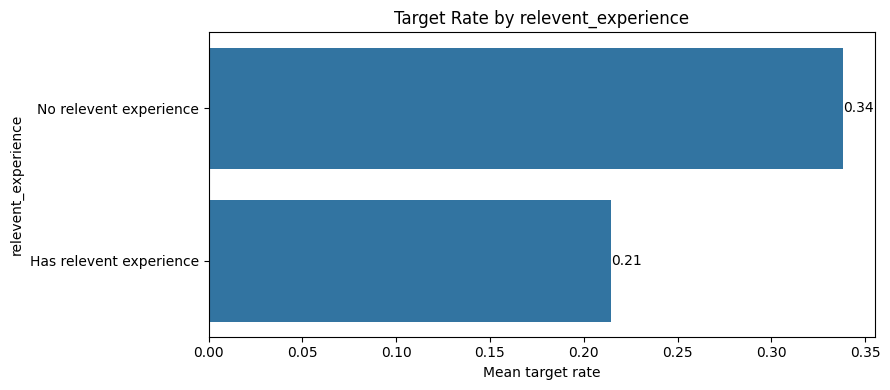

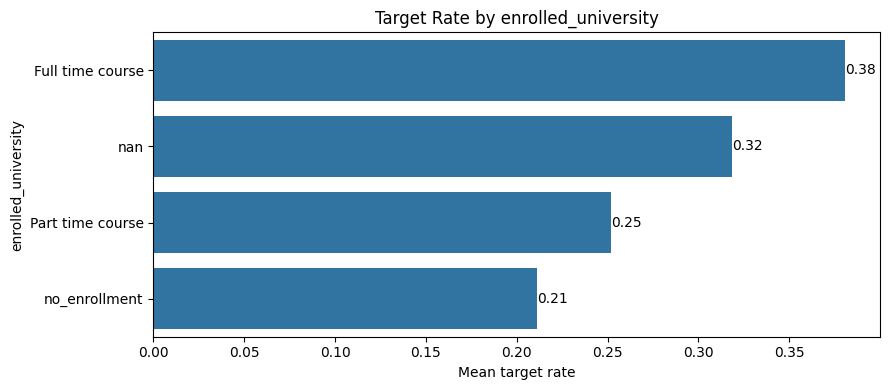

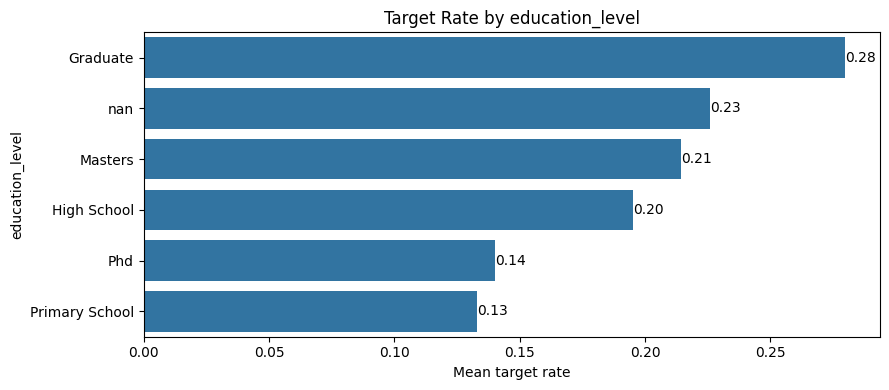

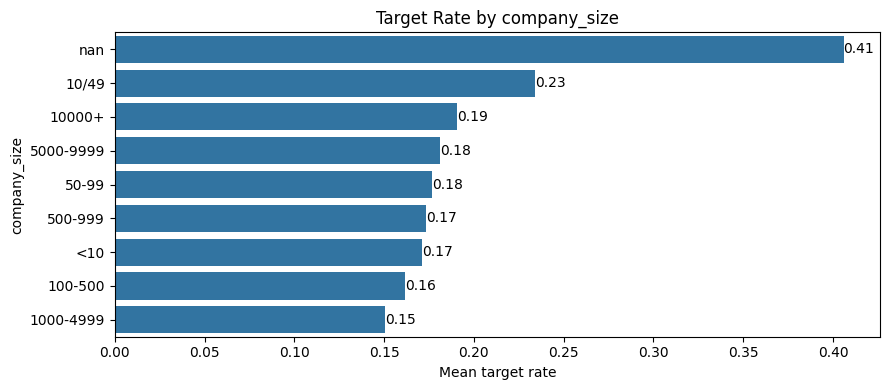

In [14]:
# Target rate by selected categorical features
eda_categorical = [
    "gender",
    "relevent_experience",
    "enrolled_university",
    "education_level",
    "company_size",
]

for col in eda_categorical:
    rate = train_raw.groupby(col, dropna=False)["target"].mean().sort_values(ascending=False)

    plt.figure(figsize=(9, 4))
    ax = sns.barplot(x=rate.values, y=rate.index.astype(str))
    plt.title(f"Target Rate by {col}")
    plt.xlabel("Mean target rate")
    plt.ylabel(col)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f")

    plt.tight_layout()
    plt.show()


In [15]:
test_ids = test_df["enrollee_id"]
df = df.drop(columns=["enrollee_id"])
test_df = test_df.drop(columns=["enrollee_id"])

In [16]:
for col in ["company_size", "company_type"]:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    test_df[f"{col}_missing"] = test_df[col].isna().astype(int)

**Handle missing values**

In [17]:
categorical_missing_cols = [
    "gender", "enrolled_university", "education_level", "major_discipline",
    "company_size", "company_type",
]
for col in categorical_missing_cols:
    df[col] = df[col].fillna("Unknown")
    test_df[col] = test_df[col].fillna("Unknown")

In [18]:
df['experience'].dtype

dtype('O')

In [19]:
# Convert experience to numeric
def convert_experience(val):
    if pd.isna(val):
        return np.nan
    if val == "<1":
        return 0
    if val == ">20":
        return 21
    return int(val)

df["experience"] = df["experience"].apply(convert_experience)
test_df["experience"] = test_df["experience"].apply(convert_experience)
df['experience'].dtype

dtype('float64')

In [20]:
df["last_new_job"].dtype

dtype('O')

In [21]:
# Convert last_new_job to numeric
def convert_last_new_job(val):
    if pd.isna(val):
        return np.nan
    if val == "never":
        return 0
    if val == ">4":
        return 5
    return int(val)

df["last_new_job"] = df["last_new_job"].apply(convert_last_new_job)
test_df["last_new_job"] = test_df["last_new_job"].apply(convert_last_new_job)
df["last_new_job"].dtype

dtype('float64')

In [22]:
numeric_cols = ["city_development_index", "training_hours", "experience", "last_new_job"]
medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)
test_df[numeric_cols] = test_df[numeric_cols].fillna(medians)

**Feature Engineering**

In [23]:
df["experience_to_last_job_ratio"] = df["experience"] / (df["last_new_job"] + 1)
test_df["experience_to_last_job_ratio"] = test_df["experience"] / (test_df["last_new_job"] + 1)

In [24]:
cdi_bins = [0, 0.6, 0.8, 1.01]
cdi_labels = ["low", "mid", "high"]
df["cdi_bin"] = pd.cut(df["city_development_index"], bins=cdi_bins, labels=cdi_labels)
test_df["cdi_bin"] = pd.cut(test_df["city_development_index"], bins=cdi_bins, labels=cdi_labels)
df["cdi_bin"] = df["cdi_bin"].astype(str)
test_df["cdi_bin"] = test_df["cdi_bin"].astype(str)

engineered_numeric_cols = ["experience_to_last_job_ratio", "company_size_missing", "company_type_missing"]

## Correlation Analysis

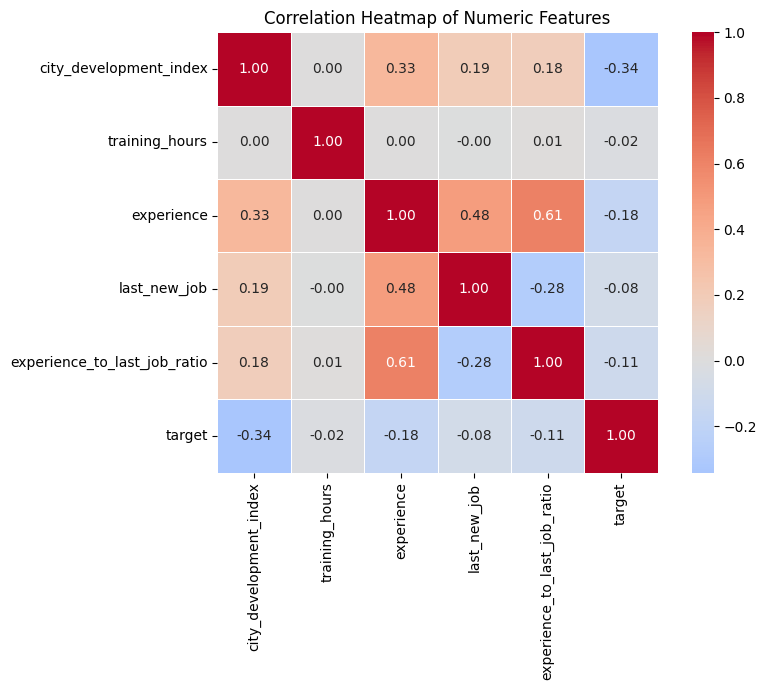

In [25]:
corr_cols = [
    "city_development_index",
    "training_hours",
    "experience",
    "last_new_job",
    "experience_to_last_job_ratio",
    "target",
]

corr_data = df[corr_cols].copy()
corr_matrix = corr_data.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


**Encode categorical features**

In [26]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Maps a categorical column to its relative frequency, learned on fit data only
    (leakage-safe: fits inside the train fold during CV / hyperparameter search)."""
    def __init__(self, column):
        self.column = column

    def fit(self, X, y=None):
        counts = X[self.column].value_counts(normalize=True)
        self.freq_map_ = counts.to_dict()
        self.default_ = 0.0  # unseen categories (e.g. new cities in test) get 0
        return self

    def transform(self, X):
        mapped = X[self.column].map(self.freq_map_).fillna(self.default_)
        return mapped.to_numpy().reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{self.column}_freq"])

onehot_cols = [
    "enrolled_university", "education_level", "major_discipline",
    "company_size", "company_type", "relevent_experience", "gender", "cdi_bin",
]
passthrough_cols = [
    "city_development_index", "training_hours", "experience", "last_new_job",
] + engineered_numeric_cols

preprocessor = ColumnTransformer(
    transformers=[
        ("city_freq", FrequencyEncoder(column="city"), ["city"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
        ("num", SimpleImputer(strategy="median"), passthrough_cols),
    ]
)

In [27]:
X = df.drop(columns=["target"])
y = df["target"].astype(int)
X_holdout = test_df.copy()

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Val size: {X_val.shape[0]}")
print(f"Class balance (train): {y_train.value_counts(normalize=True).to_dict()}")

Train size: 15326 | Val size: 3832
Class balance (train): {0: 0.750619861672974, 1: 0.24938013832702596}


In [29]:
# Handle class imbalance
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

model_configs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "param_distributions": {
            "model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs", "liblinear"],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "param_distributions": {
            "model__n_estimators": [200, 300, 500, 800],
            "model__max_depth": [None, 6, 10, 14, 20],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__max_features": ["sqrt", "log2", 0.5],
        },
    },
}

if HAS_XGB:
    model_configs["XGBoost"] = {
        "estimator": XGBClassifier(
            scale_pos_weight=scale_pos_weight, eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        "param_distributions": {
            "model__n_estimators": [200, 300, 500, 800],
            "model__max_depth": [3, 4, 6, 8],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0],
            "model__min_child_weight": [1, 3, 5],
        },
    }
else:
    print("xgboost not installed in this environment - skipping (pip install xgboost to include it)")

if HAS_LGBM:
    model_configs["LightGBM"] = {
        "estimator": LGBMClassifier(
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        ),
        "param_distributions": {
            "model__n_estimators": [200, 300, 500, 800],
            "model__num_leaves": [15, 31, 63, 127],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0],
        },
    }
else:
    print("lightgbm not installed in this environment - skipping (pip install lightgbm to include it)")

if HAS_CATBOOST:
    model_configs["CatBoost"] = {
        "estimator": CatBoostClassifier(
            auto_class_weights="Balanced", random_state=RANDOM_STATE, verbose=False
        ),
        "param_distributions": {
            "model__iterations": [200, 300, 500, 800],
            "model__depth": [4, 6, 8, 10],
            "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "model__l2_leaf_reg": [1, 3, 5, 7, 9],
        },
    }
else:
    print("catboost not installed in this environment - skipping (pip install catboost to include it)")

In [30]:
results = []
fitted_pipelines = {}
best_params_log = {}
chosen_thresholds = {}

for name, cfg in model_configs.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", cfg["estimator"])])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg["param_distributions"],
        n_iter=N_ITER,
        scoring="average_precision",
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)

    best_pipe = search.best_estimator_
    fitted_pipelines[name] = best_pipe
    best_params_log[name] = search.best_params_

    # threshold tuning: pick the threshold that maximizes F1 on validation PR curve
    y_proba = best_pipe.predict_proba(X_val)[:, 1]
    prec_curve, rec_curve, thresholds = precision_recall_curve(y_val, y_proba)
    f1_curve = np.where(
        (prec_curve + rec_curve) > 0,
        2 * prec_curve * rec_curve / (prec_curve + rec_curve + 1e-12),
        0,
    )
    best_idx = np.argmax(f1_curve[:-1])
    best_threshold = thresholds[best_idx] if len(thresholds) > 0 else 0.5
    chosen_thresholds[name] = best_threshold

    y_pred_tuned = (y_proba >= best_threshold).astype(int)

    precision = precision_score(y_val, y_pred_tuned)
    recall = recall_score(y_val, y_pred_tuned)
    f1 = f1_score(y_val, y_pred_tuned)
    pr_auc = average_precision_score(y_val, y_proba)  # threshold-independent

    results.append({
        "Model": name,
        "Best Threshold": round(float(best_threshold), 3),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4),
        "PR-AUC": round(pr_auc, 4),
    })

    print(f"\n=== {name} ===")
    print(f"Best params: {search.best_params_}")
    print(f"Tuned decision threshold (max F1 on val PR curve): {best_threshold:.3f}")
    print(classification_report(y_val, y_pred_tuned, digits=4))

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
print("\n\n===== Model comparison (sorted by PR-AUC) =====")
print(results_df.to_string(index=False))

results_df.to_csv("model_comparison.csv", index=False)


=== Logistic Regression ===
Best params: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 3}
Tuned decision threshold (max F1 on val PR curve): 0.564
              precision    recall  f1-score   support

           0     0.9027    0.7967    0.8464      2877
           1     0.5476    0.7414    0.6299       955

    accuracy                         0.7829      3832
   macro avg     0.7251    0.7690    0.7381      3832
weighted avg     0.8142    0.7829    0.7924      3832


=== Random Forest ===
Best params: {'model__n_estimators': 500, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Tuned decision threshold (max F1 on val PR curve): 0.507
              precision    recall  f1-score   support

           0     0.9146    0.8008    0.8540      2877
           1     0.5636    0.7749    0.6526       955

    accuracy                         0.7944      3832
   macro avg     0.7391    0.7879    0.7533      3832
weighted avg     0.8272 

## Model Evaluation Visualizations

In [31]:
# Validation probabilities and predictions for every fitted model
validation_outputs = {}

for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_val)[:, 1]
    threshold = chosen_thresholds[name]
    y_pred = (y_proba >= threshold).astype(int)

    validation_outputs[name] = {
        "y_proba": y_proba,
        "threshold": threshold,
        "y_pred": y_pred,
    }


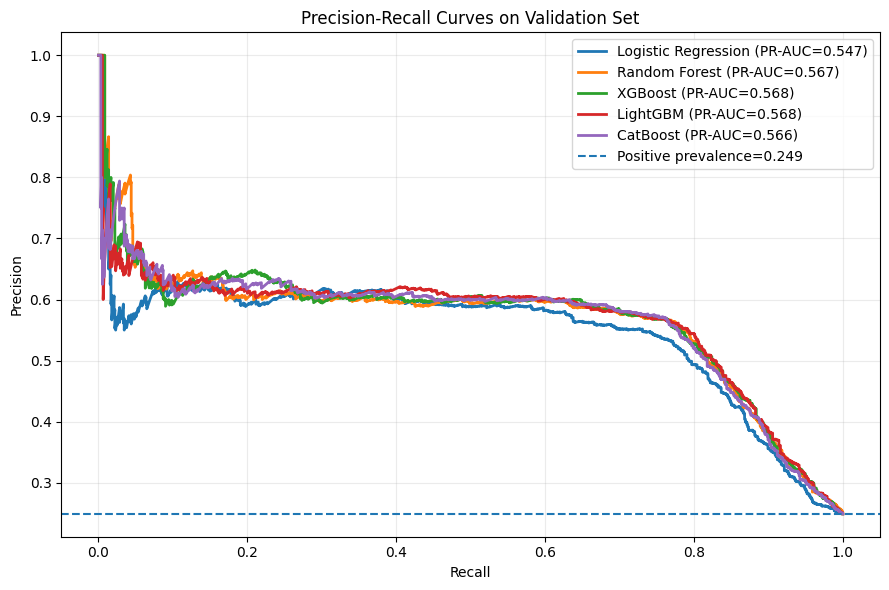

In [32]:
# Precision-Recall curves
plt.figure(figsize=(9, 6))

for name, out in validation_outputs.items():
    precision_curve, recall_curve, _ = precision_recall_curve(y_val, out["y_proba"])
    pr_auc = average_precision_score(y_val, out["y_proba"])
    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"{name} (PR-AUC={pr_auc:.3f})"
    )

baseline = y_val.mean()
plt.axhline(
    baseline,
    linestyle="--",
    linewidth=1.5,
    label=f"Positive prevalence={baseline:.3f}"
)

plt.title("Precision-Recall Curves on Validation Set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


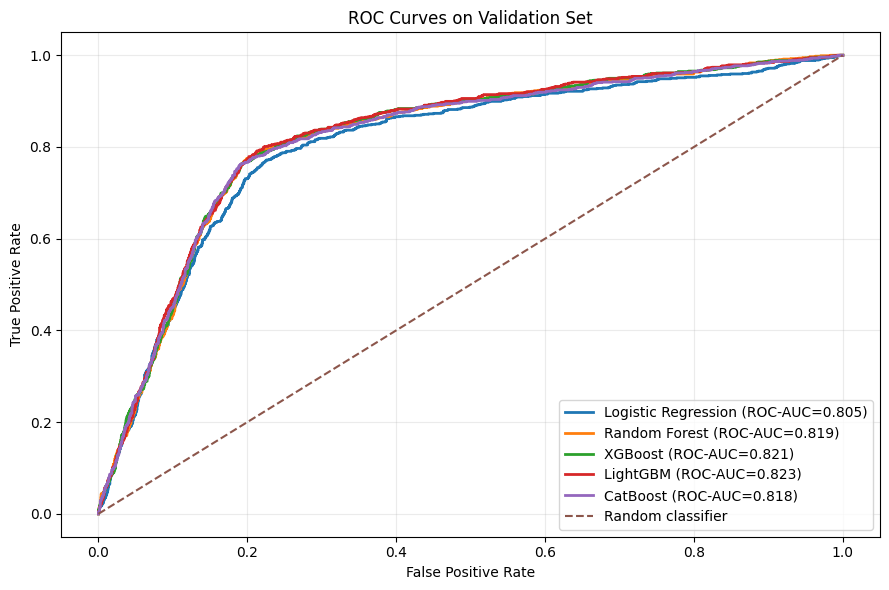

In [33]:
# ROC curves
plt.figure(figsize=(9, 6))

for name, out in validation_outputs.items():
    fpr, tpr, _ = roc_curve(y_val, out["y_proba"])
    roc_auc = roc_auc_score(y_val, out["y_proba"])
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (ROC-AUC={roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")
plt.title("ROC Curves on Validation Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


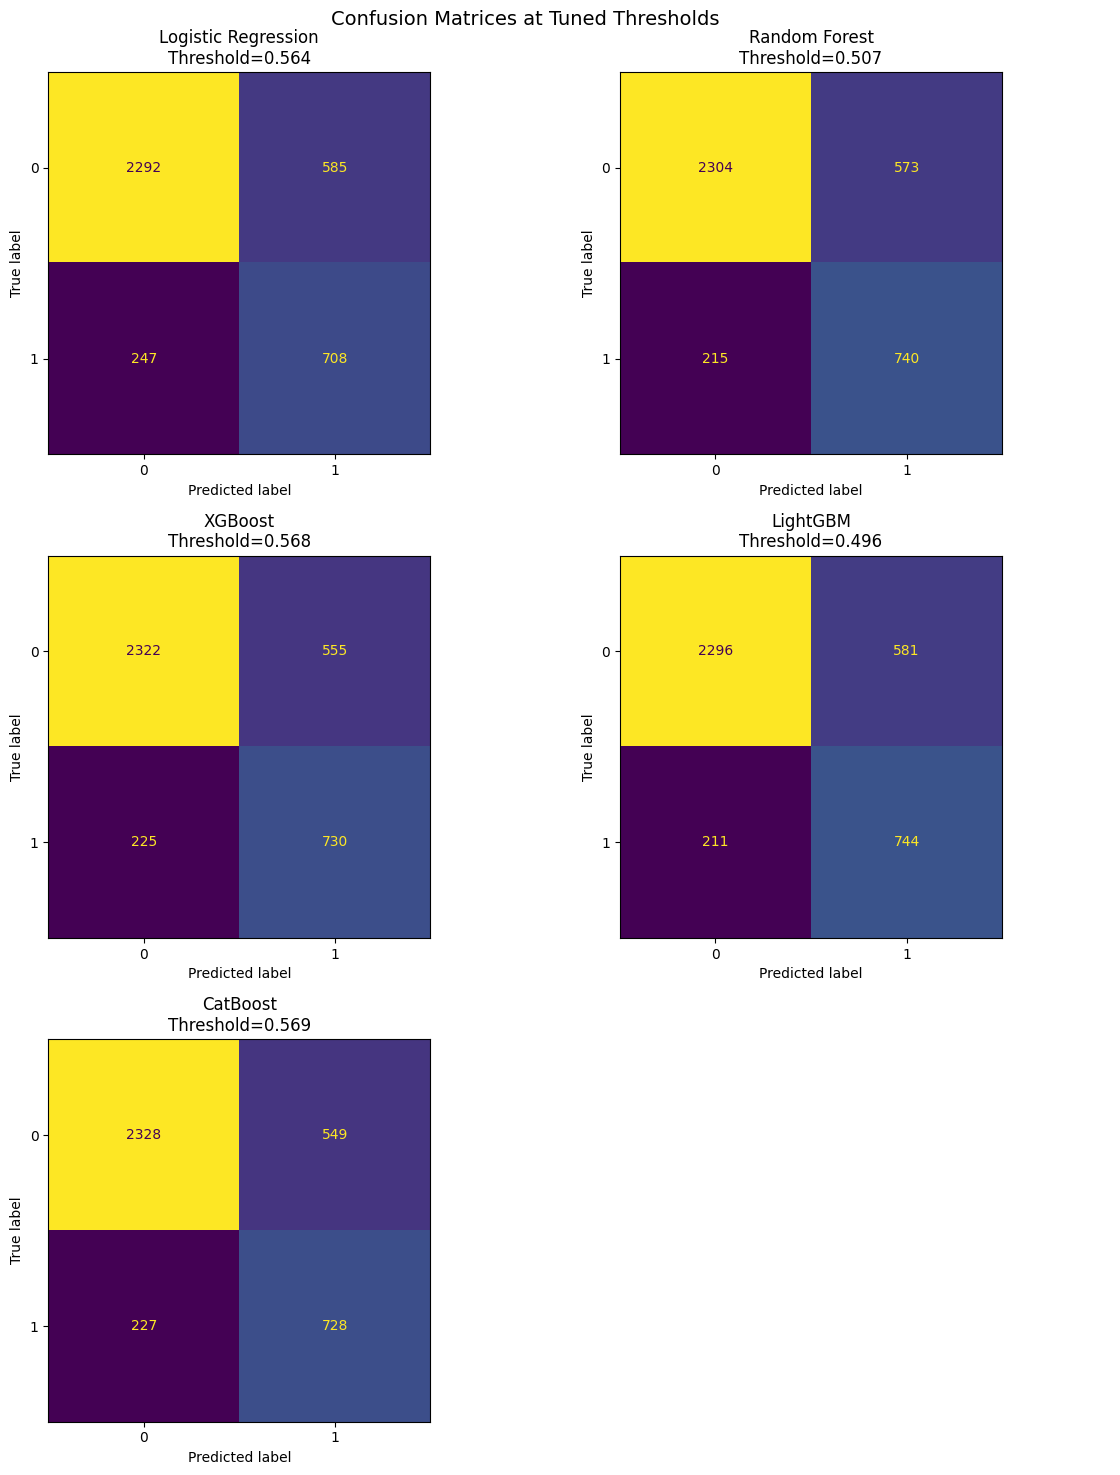

In [34]:
# Confusion matrices at each model's tuned threshold
n_models = len(validation_outputs)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 5 * n_rows)
)
axes = np.atleast_1d(axes).ravel()

for ax, (name, out) in zip(axes, validation_outputs.items()):
    cm = confusion_matrix(y_val, out["y_pred"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["0", "1"]
    )
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{name}\nThreshold={out['threshold']:.3f}")

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Confusion Matrices at Tuned Thresholds", fontsize=14)
plt.tight_layout()
plt.show()


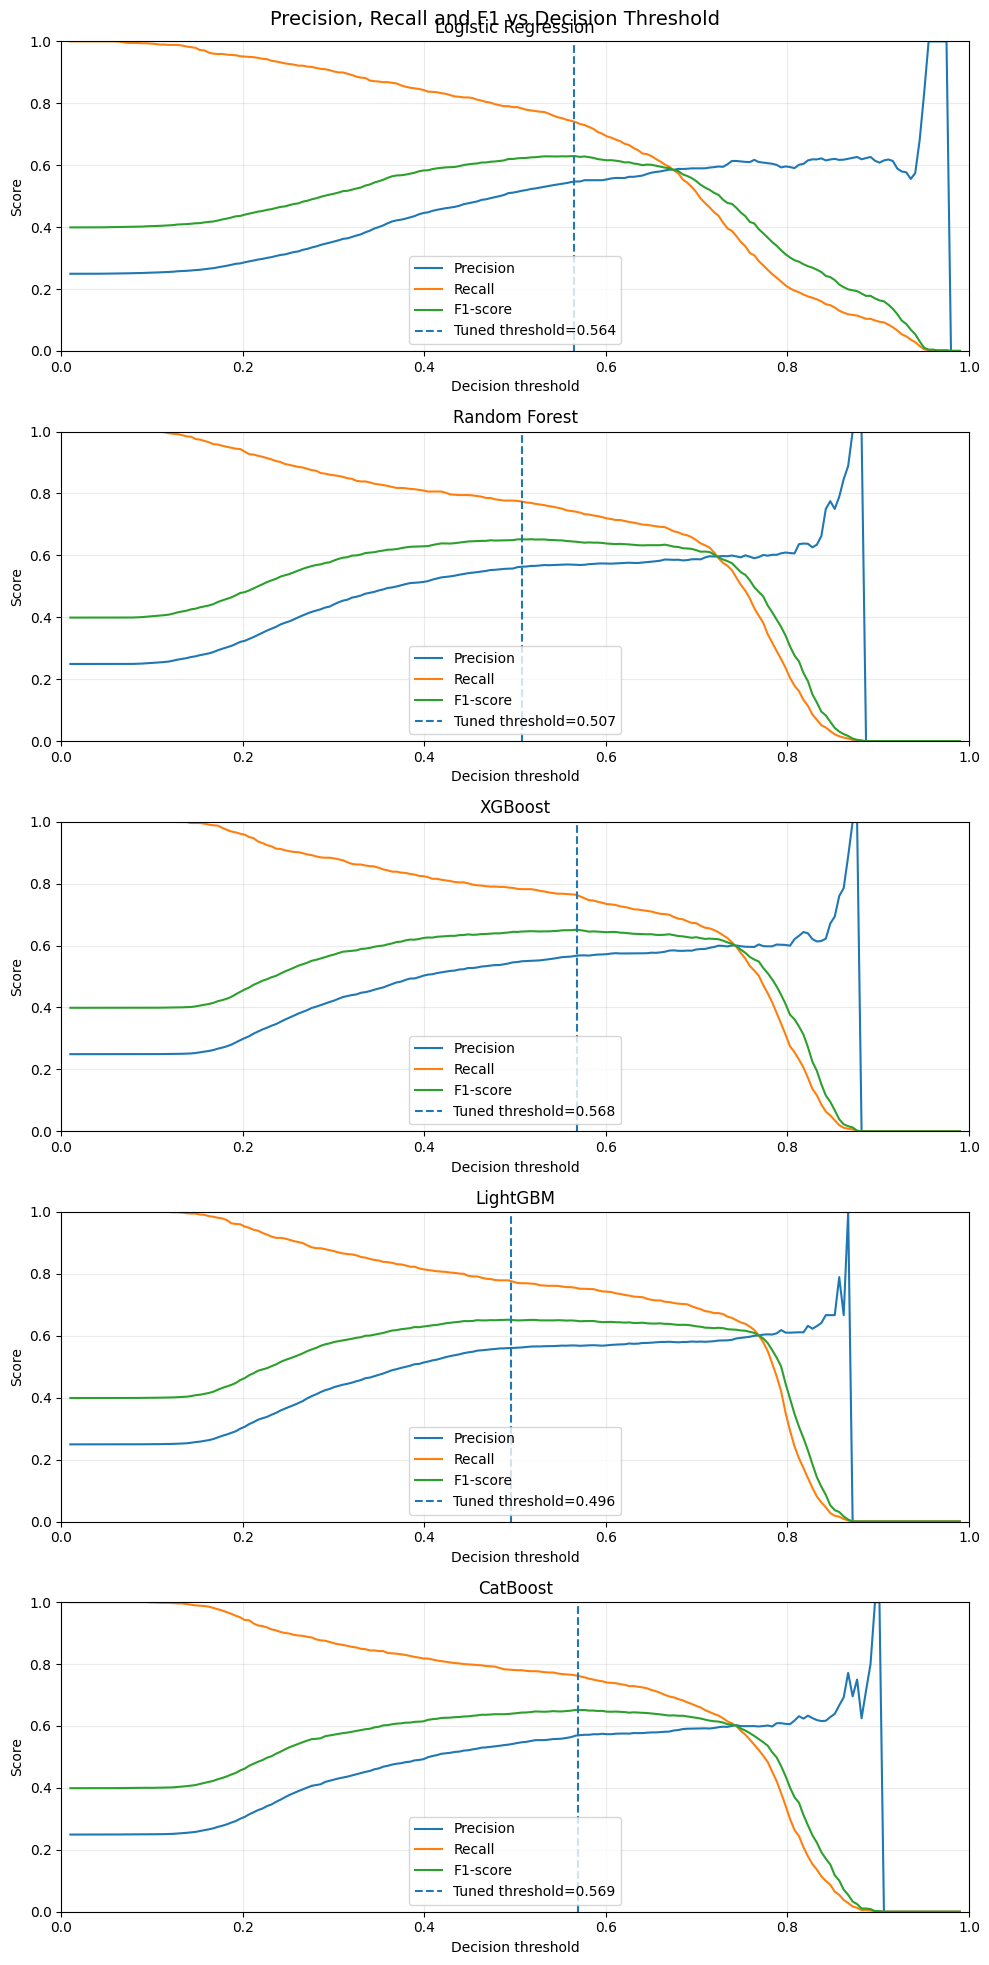

In [35]:
# Threshold vs Precision / Recall / F1 for every model
fig, axes = plt.subplots(
    n_models,
    1,
    figsize=(10, max(4, 4 * n_models)),
    squeeze=False
)
axes = axes.ravel()

for ax, (name, out) in zip(axes, validation_outputs.items()):
    thresholds = np.linspace(0.01, 0.99, 200)
    precision_values = []
    recall_values = []
    f1_values = []

    for threshold in thresholds:
        pred = (out["y_proba"] >= threshold).astype(int)
        precision_values.append(precision_score(y_val, pred, zero_division=0))
        recall_values.append(recall_score(y_val, pred, zero_division=0))
        f1_values.append(f1_score(y_val, pred, zero_division=0))

    ax.plot(thresholds, precision_values, label="Precision")
    ax.plot(thresholds, recall_values, label="Recall")
    ax.plot(thresholds, f1_values, label="F1-score")
    ax.axvline(
        out["threshold"],
        linestyle="--",
        linewidth=1.5,
        label=f"Tuned threshold={out['threshold']:.3f}"
    )

    ax.set_title(name)
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("Precision, Recall and F1 vs Decision Threshold", fontsize=14)
plt.tight_layout()
plt.show()


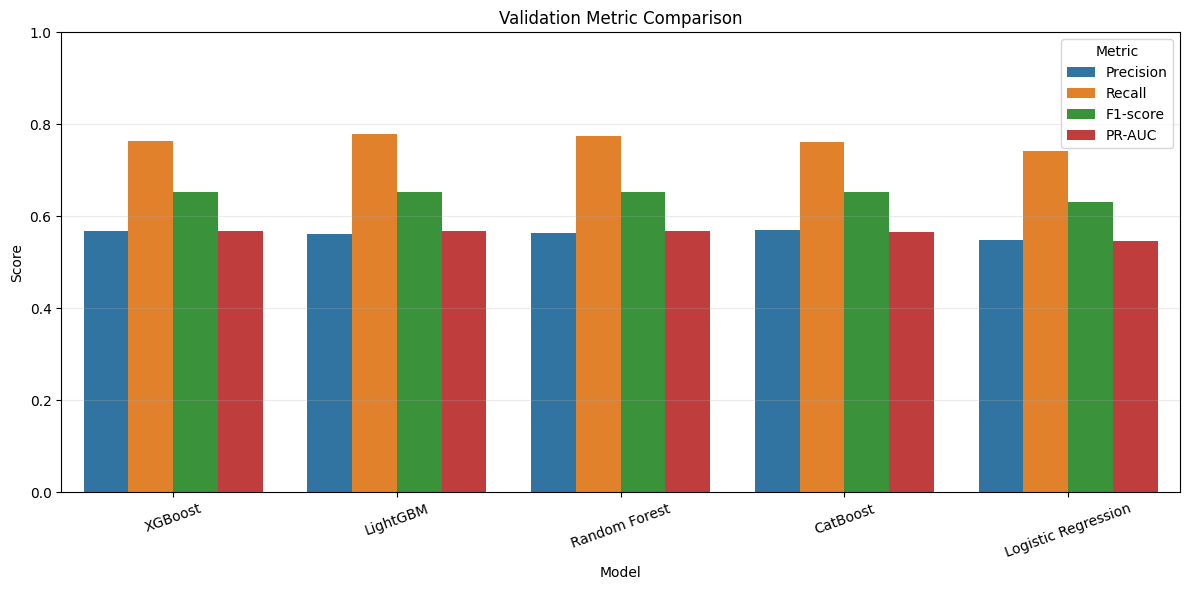

In [36]:
# Metric comparison
metric_cols = ["Precision", "Recall", "F1-score", "PR-AUC"]

plot_df = results_df[["Model"] + metric_cols].copy()
plot_long = plot_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_long, x="Model", y="Score", hue="Metric")
plt.title("Validation Metric Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [37]:
best_model_name = results_df.iloc[0]["Model"]
best_threshold = chosen_thresholds[best_model_name]
print(f"\nBest model by PR-AUC: {best_model_name} (tuned threshold: {best_threshold:.3f})")

best_estimator = model_configs[best_model_name]["estimator"]
best_params_final = {
    k.replace("model__", ""): v for k, v in best_params_log[best_model_name].items()
}
best_estimator.set_params(**best_params_final)

final_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", best_estimator)])
final_pipe.fit(X, y)

test_proba = final_pipe.predict_proba(X_holdout)[:, 1]
submission = pd.DataFrame({"enrollee_id": test_ids, "target": test_proba})
submission.to_csv("/content/sample_data/sample_submission.csv", index=False)

print("\nSaved: model_comparison.csv, submission.csv")


Best model by PR-AUC: XGBoost (tuned threshold: 0.568)

Saved: model_comparison.csv, submission.csv


## Feature Importance / Model Interpretability

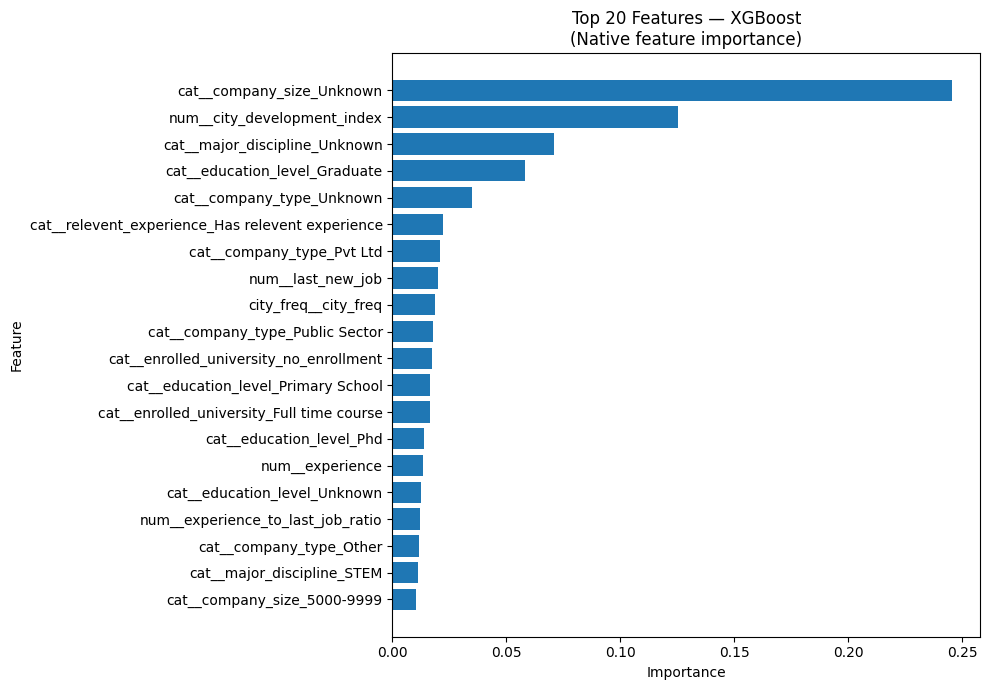

,Feature,Importance
0,cat__company_size_Unknown,0.245470
1,num__city_development_index,0.125391
2,cat__major_discipline_Unknown,0.070765
3,cat__education_level_Graduate,0.057982
4,cat__company_type_Unknown,0.034858
5,cat__relevent_experience_Has relevent experience,0.022178
6,cat__company_type_Pvt Ltd,0.020731
7,num__last_new_job,0.020103
8,city_freq__city_freq,0.018587
9,cat__company_type_Public Sector,0.017770


In [38]:
# Extract transformed feature names from the final pipeline
preprocess_final = final_pipe.named_steps["preprocess"]
model_final = final_pipe.named_steps["model"]

feature_names = preprocess_final.get_feature_names_out()

if hasattr(model_final, "feature_importances_"):
    importances = np.asarray(model_final.feature_importances_, dtype=float)
    importance_method = "Native feature importance"
elif hasattr(model_final, "coef_"):
    coef = np.asarray(model_final.coef_)
    importances = np.abs(coef[0]) if coef.ndim > 1 else np.abs(coef)
    importance_method = "Absolute coefficient magnitude"
else:
    importances = None
    importance_method = "Permutation importance"

if importances is not None:
    feature_importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    top_n = min(20, len(feature_importance_df))
    top_features = feature_importance_df.head(top_n).sort_values("Importance")

    plt.figure(figsize=(10, 7))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.title(f"Top {top_n} Features — {best_model_name}\n({importance_method})")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(feature_importance_df.head(top_n))
else:
    print(
        f"{best_model_name} does not expose native coefficients/importances. "
        "Use permutation importance below."
    )


In [39]:
# Optional model-agnostic permutation importance
# This section is useful when the final model has no native importance measure.
from sklearn.inspection import permutation_importance

if importances is None:
    perm = permutation_importance(
        final_pipe,
        X_val,
        y_val,
        scoring="average_precision",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    permutation_df = (
        pd.DataFrame({
            "Feature": X_val.columns,
            "Importance": perm.importances_mean
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

    top_n = min(20, len(permutation_df))
    top_features = permutation_df.head(top_n).sort_values("Importance")

    plt.figure(figsize=(10, 7))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.title(f"Top {top_n} Features — {best_model_name}\n(Permutation Importance)")
    plt.xlabel("Mean decrease in PR-AUC")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    display(permutation_df.head(top_n))


## Final Submission Checks

In [40]:
print("Submission shape:", submission.shape)
print("Missing values:")
print(submission.isna().sum())

print("\nUnique enrollee IDs:", submission["enrollee_id"].nunique())
print("Rows:", len(submission))

print("\nPrediction summary:")
print(submission["target"].describe())

assert submission["enrollee_id"].nunique() == len(submission), "Duplicate enrollee_id values found."
assert submission["target"].between(0, 1).all(), "Predictions must be probabilities between 0 and 1."

print("\nSubmission checks passed.")


Submission shape: (2129, 2)
Missing values:
enrollee_id    0
target         0
dtype: int64

Unique enrollee IDs: 2129
Rows: 2129

Prediction summary:
count    2129.000000
mean        0.424899
std         0.254703
min         0.103872
25%         0.203556
50%         0.311866
75%         0.726807
max         0.872571
Name: target, dtype: float64

Submission checks passed.
